# Вторая лабораторная: multi-task learning

## Импорты и константы

In [4]:
import random
import shutil
import warnings
from collections import Counter
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

In [5]:
DATASET_PATH = Path("data/DogSpeak_Dataset")

AUDIO_PATH = DATASET_PATH / "dogspeak_released"
METADATA_PATH = DATASET_PATH / "metadata.csv"

In [6]:
UNPACKED_AUDIO_PATH = Path(DATASET_PATH / "dogspeak_unpacked")
Path.mkdir(UNPACKED_AUDIO_PATH, exist_ok=True)

In [7]:
for root, dir, files in AUDIO_PATH.walk():
    for file in files:
        shutil.copyfile(
            root / Path(file),
            UNPACKED_AUDIO_PATH / Path(file)
        )

In [8]:
metadata_df = pd.read_csv(METADATA_PATH, index_col=0)

In [9]:
color_palette = dict.fromkeys([
    "maroon",
    "saddlebrown",
    "darkolivegreen",
    "olive",
    "burlywood",
    "antiquewhite",
], 0)

In [10]:
def choose_color(colors, first_n=2):
    color_n = sorted(colors, key=colors.get)[:first_n]
    color = random.choice(color_n)
    colors[color] += 1
    return color

In [11]:
PLT_FIG_SIZE = (12,6)

In [12]:
SR = librosa.get_samplerate(
    str(AUDIO_PATH / "dog_1/1_chihuahua_M_dog_1.wav")
)

## EDA

### Аудио

#### Извлекаем признаки

In [15]:
def get_audio_features(file_path, n_mfcc):
    audio, _ = librosa.load(file_path, sr=SR)

    length_sec = len(audio) / SR

    spectral_rollof = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=SR))

    mfcc = np.mean(
        librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=n_mfcc), axis=1
    )

    rms = np.mean(librosa.feature.rms(y=audio))

    zrc = np.mean(librosa.feature.zero_crossing_rate(y=audio))

    return [
        length_sec,
        spectral_rollof,
        *mfcc,
        rms,
        zrc
    ]

In [16]:
n_mfcc = 12
cols = ["filename", "length_sec", "spectral_rollof"] + [f"mfcc_{n}" for n in range(n_mfcc)] + ["rms", "zrc"]

audio_features = []
for file_path in UNPACKED_AUDIO_PATH.iterdir():
    try:
        audio_features.append([file_path.name] + get_audio_features(file_path, n_mfcc))
    except Exception as e:
        print(f"Битый {file_path.name}: {e}")

audio_df = pd.DataFrame(
    data=audio_features,
    columns=cols,
).set_index("filename")

Битый 53339_shibainu_M_dog_99.wav: 
Битый 53341_shibainu_M_dog_99.wav: 
Битый 53343_shibainu_M_dog_99.wav: 
Битый 14318_husky_M_dog_8.wav: 
Битый 53340_shibainu_M_dog_99.wav: 


#### Объединяем с лейблами

In [ ]:
audio_df = df = audio_df.merge(
    metadata_df[["breed", "sex"]],
    on="filename"
)

In [18]:
audio_df.head()

,length_sec,spectral_rollof,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,rms,zrc,breed,sex
filename,,,,,,,,,,,,,,,,,,
54706_shibainu_M_dog_103.wav,2.064,4536.298077,-230.725800,23.532927,-14.359424,-10.394773,24.812370,3.055483,26.399630,41.526676,24.456850,11.281289,0.893028,1.585290,0.133254,0.180439,shiba inu,male
55168_shibainu_F_dog_107.wav,1.024,3673.768939,-468.708527,94.995041,-8.564384,2.757638,-3.733878,-7.461303,-13.783960,5.280148,6.815764,-7.976913,-3.394359,-15.402697,0.009834,0.151545,shiba inu,female
39_chihuahua_M_dog_1.wav,1.920,4712.090164,-451.786835,21.314762,-68.935661,-16.020157,25.015490,-5.409009,17.469877,9.163590,-4.242075,-7.236269,-4.699955,0.200065,0.009974,0.259213,chihuahua,male
55420_shibainu_F_dog_107.wav,0.832,2265.914352,-284.310486,92.835098,-82.118851,-55.777489,-52.610615,-18.124668,-23.919399,-8.959300,5.742025,2.505099,7.791265,0.199131,0.058835,0.103154,shiba inu,female
55553_shibainu_F_dog_107.wav,0.384,4231.971154,-231.108170,63.746433,-29.418510,-1.119807,-37.564293,-4.891648,4.257924,6.335787,-20.512821,-7.083782,-7.117435,-10.827164,0.044848,0.171462,shiba inu,female


#### Анализируем

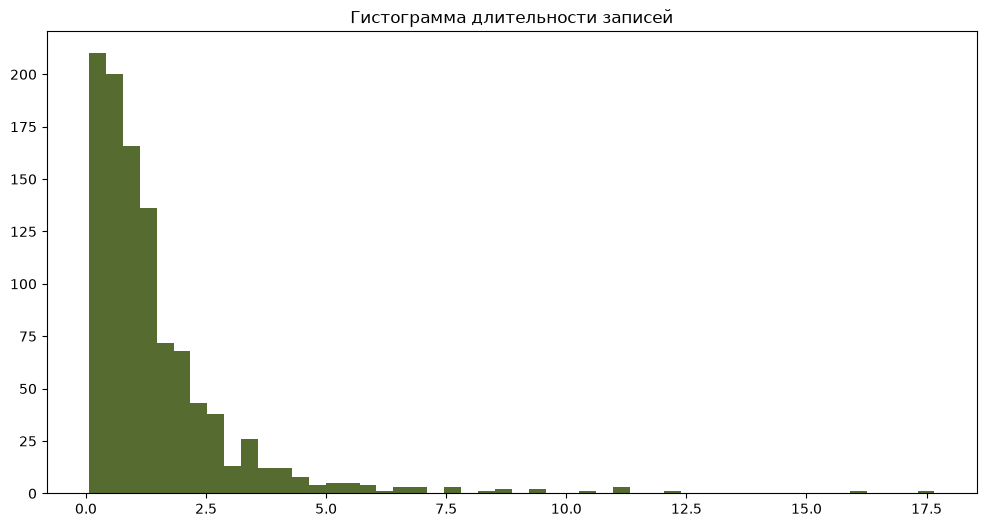

In [19]:
plt.figure(figsize=PLT_FIG_SIZE)
plt.hist(audio_df["length_sec"], bins=50, color=choose_color(color_palette))
plt.title("Гистограмма длительности записей")
plt.show()

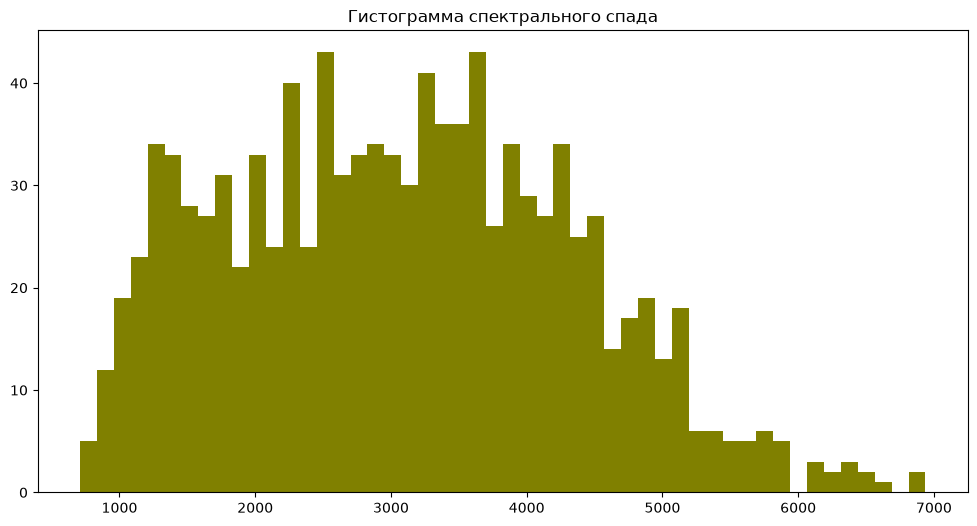

In [20]:
plt.figure(figsize=PLT_FIG_SIZE)
plt.hist(audio_df["spectral_rollof"], bins=50, color=choose_color(color_palette))
plt.title("Гистограмма спектрального спада")
plt.show()

In [21]:
mfcc_breeds = (
    df[[f"mfcc_{n}" for n in range(n_mfcc)] + ["breed"]]
    .groupby("breed")
    .mean()
)
mfcc_breeds.head()

,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11
breed,,,,,,,,,,,,
chihuahua,-380.595520,98.697884,-38.431133,-5.594398,14.049915,4.526682,12.310884,4.303880,-8.181849,-5.375780,-0.239174,-0.701229
husky,-294.991547,139.515015,-10.956113,-13.657351,-8.228612,-24.021673,-10.671098,-2.514100,-8.689827,-5.123272,-10.545605,2.492233
shiba inu,-312.729980,65.146271,-42.797989,-8.464667,-14.394237,-3.388870,0.239796,4.959723,0.792540,1.267660,-3.662056,0.529985
